In [1]:
import torch
import numpy as np
import normflows as nf
import pandas as pd

seed = 10
torch.manual_seed(seed)
np.random.seed(seed)
torch.no_grad()

import sys
import os
c_directory = os.getcwd()
sys.path.append(os.path.join(c_directory, 'FCYeast2'))

from matplotlib import pyplot as plt
import FCYeast2_simulator
import architecture

enable_cuda = True
CUDA_LAUNCH_BLOCKING=1
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
estimates = torch.load('ABC_estimates.pt',weights_only=False)
means_ABC = torch.tensor(estimates['training_means']).to(device)
sigmas_ABC = torch.tensor(estimates['training_sigmas']).to(device)
target = FCYeast2_simulator.target(means_ABC,sigmas_ABC)

In [3]:
means_ABC,sigmas_ABC

(tensor([12.8000, -0.4000,  2.0000, -0.6000, -2.4000,  0.8000, -3.4000],
        device='cuda:0'),
 tensor([0.5039, 0.5000, 0.5838, 0.5272, 0.5000, 0.7274, 0.6127],
        device='cuda:0'))

In [4]:
np.loadtxt('FCYeast2_MCMC/ABC_results_10.csv')

array([[ 1.16083660e+01, -8.14972818e-01,  7.09513202e-02, ...,
        -7.12863088e-01, -3.13484263e+00, -3.39267094e+05],
       [ 1.16083660e+01, -8.14972818e-01,  7.09513202e-02, ...,
        -7.12863088e-01, -3.13484263e+00, -3.42550406e+05],
       [ 1.16485548e+01, -8.43089938e-01,  3.18088904e-02, ...,
        -7.11864352e-01, -3.14008355e+00, -3.40602031e+05],
       ...,
       [ 1.39361954e+01, -5.54462895e-02,  3.33787417e+00, ...,
         2.20283556e+00, -2.48234963e+00, -3.32469469e+05],
       [ 1.39361954e+01, -5.54462895e-02,  3.33787417e+00, ...,
         2.20283556e+00, -2.48234963e+00, -3.32401188e+05],
       [ 1.39231930e+01, -1.01550862e-01,  3.38778782e+00, ...,
         2.26463509e+00, -2.42776513e+00, -3.31788781e+05]])

In [5]:
dils_str = ['12','23']
dils = [.12,.23]
dfs = [pd.read_csv(os.path.dirname(c_directory) +'/clean_data/complete_d={}.csv'.format(d)) for d in dils]
x = [np.log(df['FL1-A'].to_numpy()) for df in dfs]

In [6]:
s = np.loadtxt('FCYeast2_MCMC/ABC_results_10.csv')
sampled_params = s[:,:-1]
sampled_logpost = s[:,-1]

In [7]:
best_param = sampled_params[np.argmax(sampled_logpost)]

In [8]:
FCYeast2_simulator.adjust_device(device)
target_after = FCYeast2_simulator.FCYeast_simulator.target()

def sanity(best_param,x=x):
    l10 = 2.302585

    fig,ax = plt.subplots(1,2,figsize=(12,4))
    h = [axi.hist(xi.cpu().numpy().reshape(-1)/l10 ,density=True,bins=45,label='Real') for (axi,xi) in zip(ax,x)]
    
    params = FCYeast2_simulator.transform_to_arbitrary(torch.tensor(best_param).to(device).float())
    #[axi.plot(*grid_plot(xi,parami,model,log10=True),label='NF Density') for (xi,parami,axi,model) in zip(x,params,ax,models)]
    [ax[i].hist(target_after.sample(params[i,:1],params[i,1:3],params[i,3:4],N=2**16,return_lparams=False).cpu().numpy()/l10 ,
            density=True,
            bins=h[i][1],alpha=.5,label='forward simulation from MAP')for i in range(2)]

    [axi.set_xlabel(r'$\log_{10}$ I') for axi in ax]

    [axi.set_title(r'Dilution {}$/h$'.format(d)) for  (axi,d) in zip(ax,[.12,.23])]
    [axi.set_xlim(.9*xi.cpu().min()/l10,xi.cpu().max()/l10) for  (axi,xi) in zip(ax,x)]

    ax[1].legend(loc=8,ncol=3,bbox_to_anchor=(.5,1.201))
    plt.tight_layout()
    #plt.savefig('FCYeast2_MCMC/sanity_check_{}seed.png'.format(seed),dpi=600)

/tmp/ipykernel_4427/1477199508.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  params = FCYeast2_simulator.transform_to_arbitrary(torch.tensor(best_param).to(device).float())


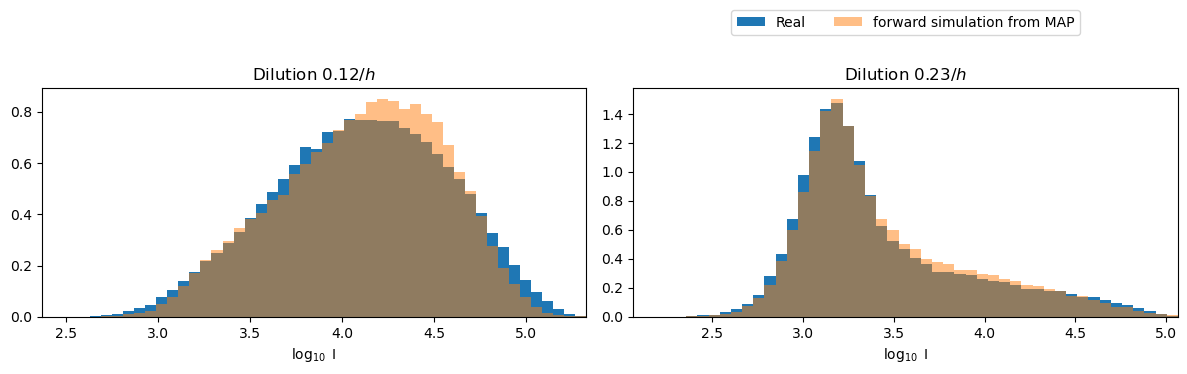

In [9]:
sanity(torch.tensor(best_param).to(device),x=[torch.tensor(xi).to(device) for xi in x])

In [10]:
torch.load('ABC_estimates.pt',weights_only=False)

{'training_means': array([12.8, -0.4,  2. , -0.6, -2.4,  0.8, -3.4], dtype=float32),
 'training_sigmas': array([0.5038527 , 0.5       , 0.58378774, 0.5271584 , 0.5       ,
        0.7273704 , 0.61273867], dtype=float32),
 '12dilution': array([14.920263, -0.4     ,  2.      , -0.6     ], dtype=float32),
 '23dilution': array([14.269676, -2.4     ,  0.8     , -3.4     ], dtype=float32)}

In [11]:
best_param

array([14.21443176, -0.09486912,  3.85926819, -0.90344286, -2.08010602,
        2.64277196, -2.24456048])

In [12]:
best_param = np.array((14.3359, -0.0531,  3.8706, -3.6293, -2.0596,  2.7300, -0.8089))

0.008247201095050257
0.01938462656231406


(array([ 0.,  0.,  0.,  0.,  0., 10.,  0.,  0.,  0.,  0.]),
 array([-0.48061537, -0.38061537, -0.28061537, -0.18061537, -0.08061537,
         0.01938463,  0.11938463,  0.21938463,  0.31938463,  0.41938463,
         0.51938463]),
 <BarContainer object of 10 artists>)

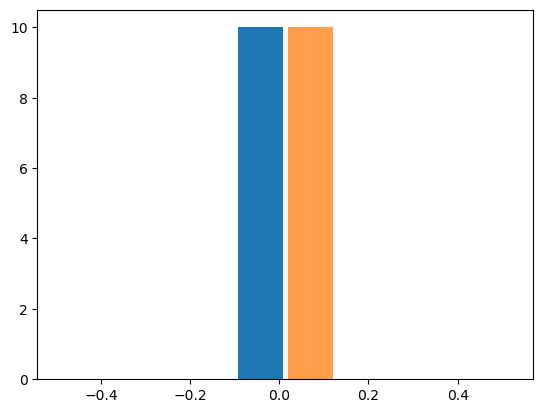

In [13]:
lact = np.exp(best_param[4])
lina = np.exp(best_param[5])
frac = lact/(lact+lina)
print(frac)
plt.hist(frac,label = 'lowstress',density=True)

lact = np.exp(best_param[1])
lina = np.exp(best_param[2])
frac = lact/(lact+lina)
print(frac)
plt.hist(frac,label = 'highstress',alpha=.75,density=True)


In [14]:
s.std(axis=0).clip(.25)

array([9.14862330e-01, 2.50000000e-01, 1.19155229e+00, 4.53264762e-01,
       2.53802377e-01, 1.13153280e+00, 7.14005532e-01, 2.70198546e+03])

In [15]:
lp_abc = np.loadtxt('FCYeast2_MCMC/ABC_results_10.csv')[-10000:,-1]
g_nf = np.loadtxt('FCYeast2_MCMC/mcmc_real_results_1337seed_116224datapoints.csv')[-100000:]
lp_nf = g_nf[:,-1]

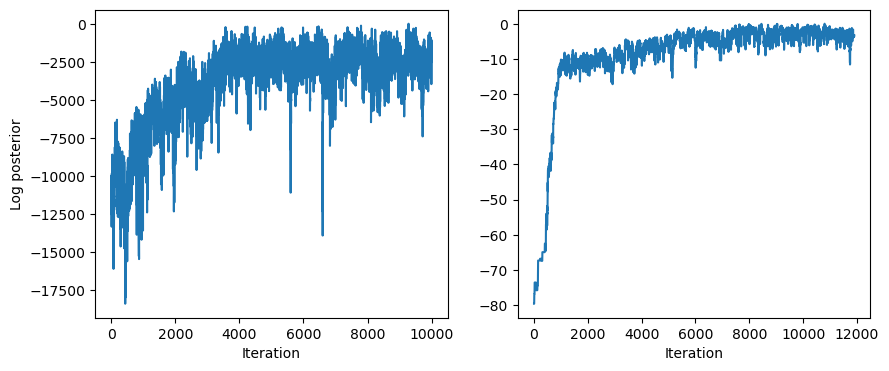

In [16]:
fig,ax = plt.subplots(1,2,figsize=(10,4))

ax[0].plot(lp_abc-lp_abc.max())
ax[1].plot(lp_nf-lp_nf.max())
ax[0].set_ylabel('Log posterior')
[axi.set_xlabel('Iteration') for axi in ax]
plt.savefig('abc_comp.png',dpi=600)

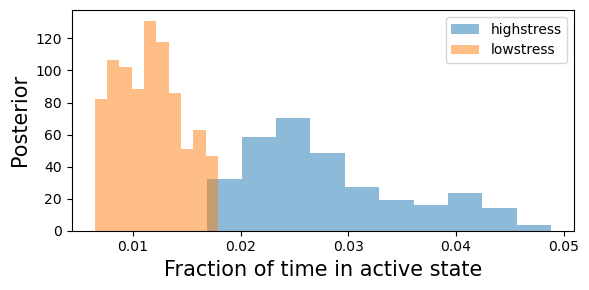

In [18]:
plt.figure(figsize=(6, 3)) 

lact = np.exp(s[-1000:,1])
lina = np.exp(s[-1000:,2])
frac = lact/(lact+lina)
plt.hist(frac,label = 'highstress',alpha=.5,density=True)

lact = np.exp(s[-1000:,4])
lina = np.exp(s[-1000:,5])
frac = lact/(lact+lina)
plt.hist(frac,label = 'lowstress',alpha=.5,density=True)


plt.ylabel('Posterior',fontsize=15)
plt.legend()
plt.xlabel('Fraction of time in active state',fontsize=15)
plt.tight_layout()
plt.savefig('frac',dpi=600)

In [19]:
np.argmax(sampled_logpost)

9282